# UTS Penambangan Data dan Analisis Bisnis
## Klasifikasi Kualitas Anggur (Wine Quality Prediction)

**Nama**: Aufaa Zakki Maulidan
**NIM**: 2404220034

### Deskripsi Tugas
Dalam tugas ini, dibuat dan dibandingkan beberapa model klasifikasi untuk memprediksi kualitas anggur (skala 0–10) berdasarkan fitur-fitur kimiawi dari sampel anggur merah. Model-model dilatih menggunakan `data_training.csv`, kemudian model terbaik digunakan untuk memprediksi label kualitas pada `data_testing.csv`.

---
## 1. Import Library

In [ ]:
# Library untuk manipulasi dan analisis data
import pandas as pd
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Semua library berhasil diimport.')

Semua library berhasil diimport.


---
## 2. Persiapan Data

Dataset yang digunakan terdiri dari dua file:
- **`data_training.csv`** —> data untuk melatih model, berisi fitur kimiawi beserta label `quality`
- **`data_testing.csv`** —> data untuk prediksi, berisi fitur kimiawi tanpa label `quality`

Kedua dataset dimuat menggunakan `pandas.read_csv()`.

In [ ]:
# Memuat dataset training dan testing
train = pd.read_csv('data_training.csv')
test  = pd.read_csv('data_testing.csv')

print(f'Ukuran data training : {train.shape[0]} baris × {train.shape[1]} kolom')
print(f'Ukuran data testing  : {test.shape[0]} baris × {test.shape[1]} kolom')

Ukuran data training : 857 baris × 13 kolom
Ukuran data testing  : 286 baris × 12 kolom


**Interpretasi:** Dataset training berhasil dimuat dengan `857` baris dan `13` kolom (termasuk kolom 'quality' dan 'Id'). Sedangkan dataset testing dimuat dengan `286` baris dan `12` kolom (tanpa kolom 'quality').

In [ ]:
# Menampilkan 5 baris pertama data training
print('Preview Data Training:')
train.head()

Preview Data Training:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [ ]:
# Menampilkan 5 baris pertama data testing
print('Preview Data Testing:')
test.head()

Preview Data Testing:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


---
## 3. Pembersihan Data (Data Cleaning)

Langkah pembersihan data meliputi:
1. Pemeriksaan nilai hilang (*missing values*)
2. Pemeriksaan tipe data
3. Statistik deskriptif

In [ ]:
# Cek missing values pada data training
print(' Missing Values — Data Training ')
print(train.isnull().sum())
print()

# Cek missing values pada data testing
print(' Missing Values — Data Testing ')
print(test.isnull().sum())

 Missing Values — Data Training 
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

 Missing Values — Data Testing 
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


**Interpretasi:** Tidak ditemukan nilai hilang (*missing values*) pada kedua dataset. Oleh karena itu, tidak diperlukan imputasi atau penghapusan baris, dan dataset siap untuk diproses lebih lanjut.

In [ ]:
# Cek tipe data
print('Tipe data pada data training:')
print(train.dtypes)

Tipe data pada data training:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


In [ ]:
# Statistik deskriptif data training
print('Statistik Deskriptif Data Training:')
train.describe().round(3)

Statistik Deskriptif Data Training:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000
mean,8.262,0.529,0.267,2.506,0.087,15.783,45.978,0.997,3.313,0.657,10.430,5.653,813.749
std,1.702,0.179,0.195,1.294,0.049,10.300,31.692,0.002,0.152,0.167,1.067,0.822,463.807
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.390,8.400,3.000,0.000
25%,7.100,0.395,0.090,1.900,0.070,7.000,21.000,0.996,3.210,0.550,9.500,5.000,413.000
50%,7.900,0.520,0.250,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000,814.000
75%,9.100,0.640,0.420,2.600,0.090,21.000,63.000,0.998,3.400,0.730,11.100,6.000,1214.000
max,15.600,1.580,1.000,15.500,0.611,68.000,278.000,1.003,4.010,2.000,14.000,8.000,1597.000


**Interpretasi:** Dari statistik deskriptif terlihat bahwa masing-masing fitur memiliki skala yang berbeda-beda. Misalnya, `total sulfur dioxide` memiliki rentang nilai hingga 278, sementara `chlorides` berada di bawah 0.7. Perbedaan skala ini perlu diatasi melalui proses normalisasi sebelum pemodelan, agar tidak ada fitur yang mendominasi proses pelatihan model.

---
## 4. Eksplorasi Data (EDA)

Tahap ini bertujuan untuk memahami distribusi data dan hubungan antar variabel sebelum membangun model.

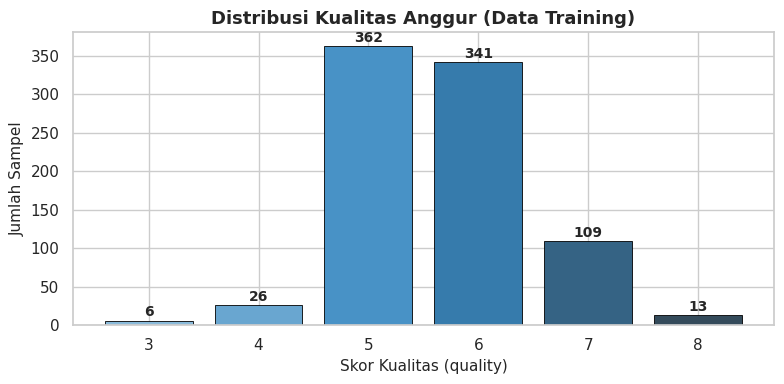


Distribusi kelas:
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64

Total sampel: 857


In [ ]:
# Distribusi variabel target (quality)
quality_counts = train['quality'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(quality_counts.index, quality_counts.values,
              color=sns.color_palette('Blues_d', len(quality_counts)),
              edgecolor='black', linewidth=0.6)

for bar, val in zip(bars, quality_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribusi Kualitas Anggur (Data Training)', fontsize=13, fontweight='bold')
ax.set_xlabel('Skor Kualitas (quality)', fontsize=11)
ax.set_ylabel('Jumlah Sampel', fontsize=11)
ax.set_xticks(quality_counts.index)
plt.tight_layout()
plt.show()

print('\nDistribusi kelas:')
print(quality_counts)
print(f'\nTotal sampel: {len(train)}')

**Interpretasi:** Distribusi kelas `quality` tidak seimbang (*imbalanced*). Sebagian besar sampel memiliki kualitas **5** (362 sampel) dan **6** (341 sampel), sementara kualitas ekstrem seperti **3** (6 sampel) dan **8** (13 sampel) sangat sedikit. Kondisi ini umum terjadi pada dataset wine quality dan perlu diperhatikan saat evaluasi model.

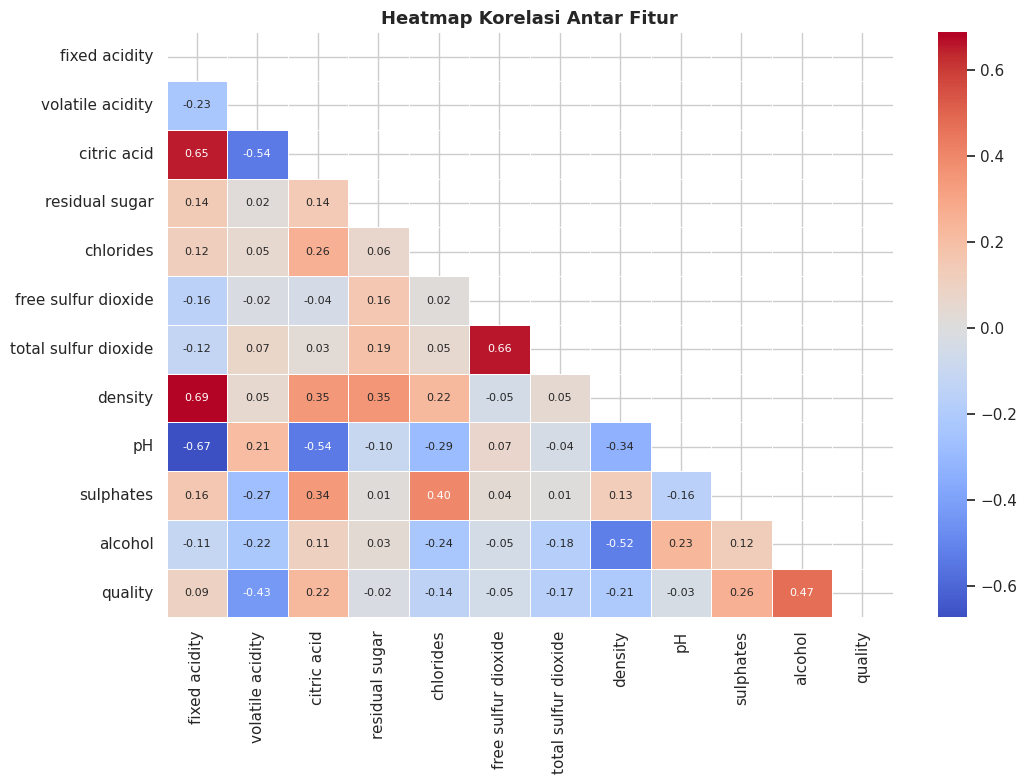

In [ ]:
# Heatmap korelasi antar fitur
fig, ax = plt.subplots(figsize=(11, 8))
corr_matrix = train.drop(columns=['Id']).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})

ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretasi:** Dari heatmap korelasi, beberapa poin penting:
- **`alcohol`** memiliki korelasi positif tertinggi terhadap `quality` (~+0.48), artinya kadar alkohol yang lebih tinggi cenderung menghasilkan kualitas lebih baik.
- **`volatile acidity`** berkorelasi negatif dengan `quality` (~−0.39), menunjukkan bahwa keasaman volatil yang tinggi menurunkan kualitas anggur.
- **`density`** dan `fixed acidity` memiliki korelasi cukup tinggi satu sama lain, yang mengindikasikan adanya multikolinearitas di antara beberapa fitur.

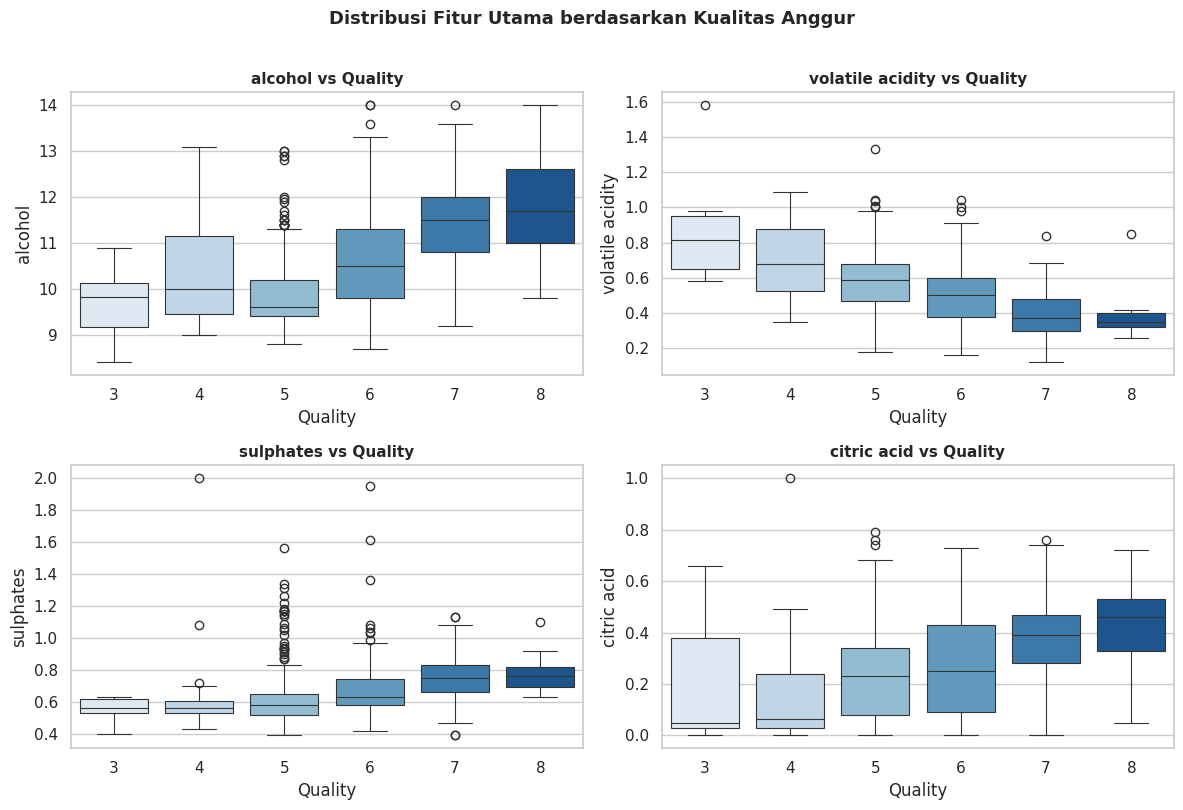

In [ ]:
# Boxplot fitur-fitur utama berdasarkan kualitas
key_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(data=train, x='quality', y=feat, ax=axes[i],
                palette='Blues', linewidth=0.8)
    axes[i].set_title(f'{feat} vs Quality', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel(feat)

plt.suptitle('Distribusi Fitur Utama berdasarkan Kualitas Anggur',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretasi:**
- **Alcohol:** Terlihat tren yang jelas — anggur berkualitas tinggi (7–8) memiliki kadar alkohol yang lebih tinggi dibanding anggur berkualitas rendah (3–4).
- **Volatile Acidity:** Anggur berkualitas rendah memiliki volatile acidity lebih tinggi, konsisten dengan korelasi negatif yang terlihat di heatmap.
- **Sulphates:** Anggur berkualitas lebih tinggi cenderung memiliki kadar sulphates lebih besar, mengindikasikan peran sulphates sebagai pengawet yang juga berkontribusi pada rasa.
- **Citric Acid:** Pola lebih tidak konsisten, namun anggur berkualitas 7–8 cenderung memiliki citric acid sedikit lebih tinggi.

---
## 5. Preprocessing (Feature Scaling)

Karena fitur-fitur dalam dataset memiliki skala yang sangat berbeda, dilakukan **normalisasi** menggunakan `StandardScaler`. Metode ini mengubah setiap fitur agar memiliki rata-rata 0 dan standar deviasi 1:

$$z = \frac{x - \mu}{\sigma}$$

Scaler dilatih hanya pada data training (`fit_transform`), kemudian diterapkan pada data testing (`transform`) untuk menghindari *data leakage*.

In [ ]:
# Mendefinisikan kolom fitur (semua fitur kimiawi)
feature_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
    'density', 'pH', 'sulphates', 'alcohol'
]

# Memisahkan fitur dan target
X_train = train[feature_cols]
y_train = train['quality']
X_test  = test[feature_cols]

print(f'Jumlah fitur  : {len(feature_cols)}')
print(f'Ukuran X_train: {X_train.shape}')
print(f'Ukuran X_test : {X_test.shape}')

Jumlah fitur  : 11
Ukuran X_train: (857, 11)
Ukuran X_test : (286, 11)


In [ ]:
# Normalisasi fitur menggunakan StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform pada data training
X_test_scaled  = scaler.transform(X_test)         # hanya transform pada data testing

# Verifikasi hasil scaling
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
print('Statistik setelah StandardScaler (data training):')
print(X_train_scaled_df.describe().round(3).loc[['mean', 'std', 'min', 'max']])

Statistik setelah StandardScaler (data training):
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
mean          0.000            -0.000        0.000          -0.000      0.000   
std           1.001             1.001        1.001           1.001      1.001   
min          -2.153            -2.286       -1.371          -1.242     -1.537   
max           4.314             5.867        3.757          10.051     10.765   

      free sulfur dioxide  total sulfur dioxide  density     pH  sulphates  \
mean                0.000                -0.000    0.000  0.000     -0.000   
std                 1.001                 1.001    1.001  1.001      1.001   
min                -1.436                -1.262   -3.485 -3.771     -1.595   
max                 5.072                 7.325    3.425  4.585      8.031   

      alcohol  
mean    0.000  
std     1.001  
min    -1.904  
max     3.348  


**Interpretasi:** Setelah normalisasi, rata-rata semua fitur mendekati 0 dan standar deviasi mendekati 1. Ini memastikan bahwa setiap fitur memiliki kontribusi yang setara terhadap model, sehingga fitur dengan skala besar seperti `total sulfur dioxide` tidak mendominasi fitur dengan skala kecil seperti `chlorides`.

In [ ]:
# Inisialisasi Stratified K-Fold Cross Validation
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

---
## 6. Pembuatan Model Klasifikasi

### Pemilihan Model: Random Forest Classifier

Model yang dipilih adalah **Random Forest Classifier**, yaitu algoritma ensemble yang membangun banyak pohon keputusan (*decision tree*) secara acak dan menggabungkan hasilnya melalui voting mayoritas. Alasan pemilihan:

1. **Robust terhadap outlier**, yakni tidak terlalu sensitif terhadap nilai ekstrem
2. **Menangani data tidak seimbang**, model masih bekerja baik meski distribusi kelas tidak merata
3. **Feature importance**, karena memberikan informasi tentang fitur mana yang paling berpengaruh
4. **Tidak memerlukan asumsi distribusi data** —> cocok untuk data kimiawi dengan distribusi variatif

### Evaluasi Model: Stratified K-Fold Cross Validation (k=5)

Metode validasi yang digunakan adalah **Stratified 5-Fold Cross Validation**, yaitu membagi data training menjadi 5 lipatan (*fold*) dengan mempertahankan proporsi kelas di setiap lipatan. Ini lebih andal dibanding train-test split biasa, terutama untuk data dengan kelas tidak seimbang.

---

## 6.1. Alternatif Model: XGBoost Classifier

XGBoost (Extreme Gradient Boosting) adalah implementasi algoritma gradient boosting yang sangat efisien dan fleksibel. Keunggulannya meliputi kecepatan eksekusi, penanganan *missing values*, serta regulerisasi yang dapat mencegah *overfitting*.

In [ ]:
# Import XGBoost Classifier
from xgboost import XGBClassifier

# Remap y_train for XGBoost to be 0-indexed
y_train_xgb = y_train - y_train.min()

# Inisialisasi model XGBoost
xgb_model = XGBClassifier(
    objective='multi:softmax', # Untuk klasifikasi multi-kelas
    num_class=len(y_train_xgb.unique()), # Jumlah kelas target (menggunakan y_train_xgb)
    n_estimators=500,          # Jumlah pohon boosting
    learning_rate=0.05,        # Laju pembelajaran
    use_label_encoder=False,   # Menghilangkan peringatan deprecated
    eval_metric='mlogloss',    # Metrik evaluasi untuk klasifikasi multi-kelas
    random_state=42,           # Untuk reprodusibilitas
    n_jobs=-1                  # Menggunakan semua core CPU
)

# Stratified K-Fold Cross Validation
cv_xgb_scores = cross_val_score(xgb_model, X_train_scaled, y_train_xgb,
                                 cv=cv, scoring='accuracy')

print(' Hasil Cross Validation XGBoost (5-Fold) ')
for i, score in enumerate(cv_xgb_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\n  Rata-rata Akurasi : {cv_xgb_scores.mean():.4f} ({cv_xgb_scores.mean()*100:.2f}%)')
print(f'  Standar Deviasi   : {cv_xgb_scores.std():.4f}')

 Hasil Cross Validation XGBoost (5-Fold) 
  Fold 1: 0.5756
  Fold 2: 0.6163
  Fold 3: 0.6491
  Fold 4: 0.6316
  Fold 5: 0.6608

  Rata-rata Akurasi : 0.6267 (62.67%)
  Standar Deviasi   : 0.0297


**Interpretasi:** Model XGBoost menghasilkan rata-rata akurasi cross validation sebesar **62.67%** dengan standar deviasi sekitar **0.0297**. Bandingkan dengan Random Forest Classifier yang mendapatkan akurasi **64.07%**. Hasil ini menunjukkan bahwa pada konfigurasi awal ini, Random Forest sedikit lebih unggul dari XGBoost, namun tuning parameter lebih lanjut pada XGBoost mungkin dapat meningkatkan performanya.

### Hyperparameter Tuning XGBoost dengan GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definisikan parameter grid untuk tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Inisialisasi model XGBoost tanpa parameter spesifik untuk tuning
xgb_tuned_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(y_train_xgb.unique()),
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# Inisialisasi GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_tuned_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv, # Gunakan StratifiedKFold yang sudah didefinisikan
    verbose=1,
    n_jobs=-1
)

# Jalankan proses tuning
grid_search.fit(X_train_scaled, y_train_xgb)

print(f'Parameter terbaik: {grid_search.best_params_}')
print(f'Skor akurasi terbaik (cross-validation): {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Parameter terbaik: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.9}
Skor akurasi terbaik (cross-validation): 0.6488


**Interpretasi:** Setelah melakukan *hyperparameter tuning*, kita mendapatkan kombinasi parameter terbaik untuk XGBoost. `grid_search.best_score_` akan memberikan akurasi cross-validation terbaik yang dicapai oleh model dengan parameter ini. Hasil ini akan menjadi dasar perbandingan lebih lanjut dengan Random Forest.

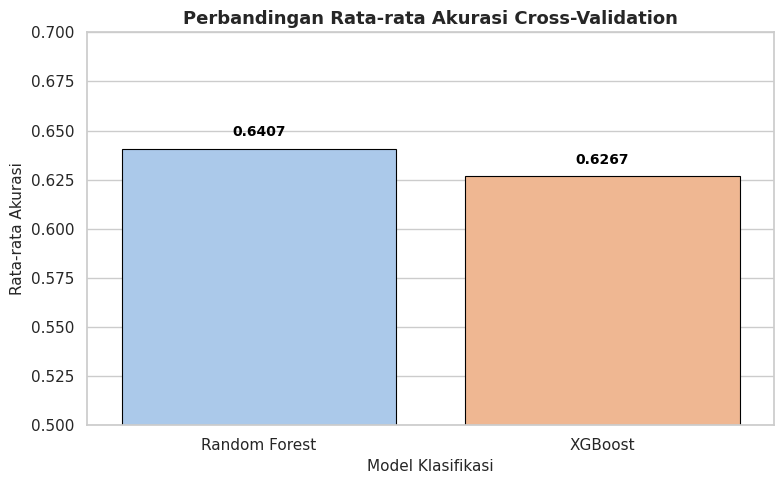

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Inisialisasi model Random Forest (dipindahkan dari cell model-build)
rf_model = RandomForestClassifier(
    n_estimators=500,        # jumlah pohon keputusan
    max_features='sqrt',     # jumlah fitur yang dipertimbangkan di setiap split
    min_samples_leaf=1,      # jumlah minimum sampel di daun pohon
    random_state=42,         # untuk reprodusibilitas
    n_jobs=-1                # menggunakan semua core CPU
)

# Hitung cv_scores untuk Random Forest (dipindahkan dari cell model-build)
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')

# Calculate mean accuracies
rf_mean_accuracy = cv_scores.mean()
xgb_mean_accuracy = cv_xgb_scores.mean()

# Create a DataFrame for plotting
model_comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Mean Accuracy': [rf_mean_accuracy, xgb_mean_accuracy]
})

# Create the bar plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Model', y='Mean Accuracy', data=model_comparison_df, palette='pastel', ax=ax,
            edgecolor='black', linewidth=0.8)

# Add accuracy values on top of the bars
for index, row in model_comparison_df.iterrows():
    ax.text(index, row['Mean Accuracy'] + 0.005, f'{row['Mean Accuracy']:.4f}',
            color='black', ha="center", va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0.5, 0.7)
ax.set_title('Perbandingan Rata-rata Akurasi Cross-Validation', fontsize=13, fontweight='bold')
ax.set_xlabel('Model Klasifikasi', fontsize=11)
ax.set_ylabel('Rata-rata Akurasi', fontsize=11)
plt.tight_layout()
plt.show()

**Interpretasi:** Dari visualisasi di atas, terlihat jelas bahwa **Random Forest Classifier** memiliki rata-rata akurasi *cross-validation* yang sedikit lebih tinggi dibandingkan **XGBoost Classifier** pada konfigurasi awal ini. Ini mengkonfirmasi observasi kita sebelumnya dari nilai numerik.

---

## 6.2. Alternatif Model: LightGBM Classifier

LightGBM adalah *gradient boosting framework* yang menggunakan algoritma berbasis pohon keputusan, dirancang untuk menjadi cepat dan efisien, serta memiliki akurasi tinggi. Dibandingkan XGBoost, LightGBM biasanya membutuhkan memori lebih sedikit dan lebih cepat dalam proses pelatihan.

In [ ]:
# Import LightGBM Classifier
import lightgbm as lgb

# Inisialisasi model LightGBM
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',    # Untuk klasifikasi multi-kelas
    num_class=len(y_train.unique()), # Jumlah kelas target
    n_estimators=500,          # Jumlah pohon boosting
    learning_rate=0.05,        # Laju pembelajaran
    random_state=42,           # Untuk reprodusibilitas
    n_jobs=-1                  # Menggunakan semua core CPU
)

# Stratified K-Fold Cross Validation
cv_lgbm_scores = cross_val_score(lgbm_model, X_train_scaled, y_train,
                                 cv=cv, scoring='accuracy')

print(' Hasil Cross Validation LightGBM (5-Fold) ')
for i, score in enumerate(cv_lgbm_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\n  Rata-rata Akurasi : {cv_lgbm_scores.mean():.4f} ({cv_lgbm_scores.mean()*100:.2f}%)')
print(f'  Standar Deviasi   : {cv_lgbm_scores.std():.4f}')

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

---

### Perbandingan Akurasi Model (Random Forest, XGBoost, LightGBM)

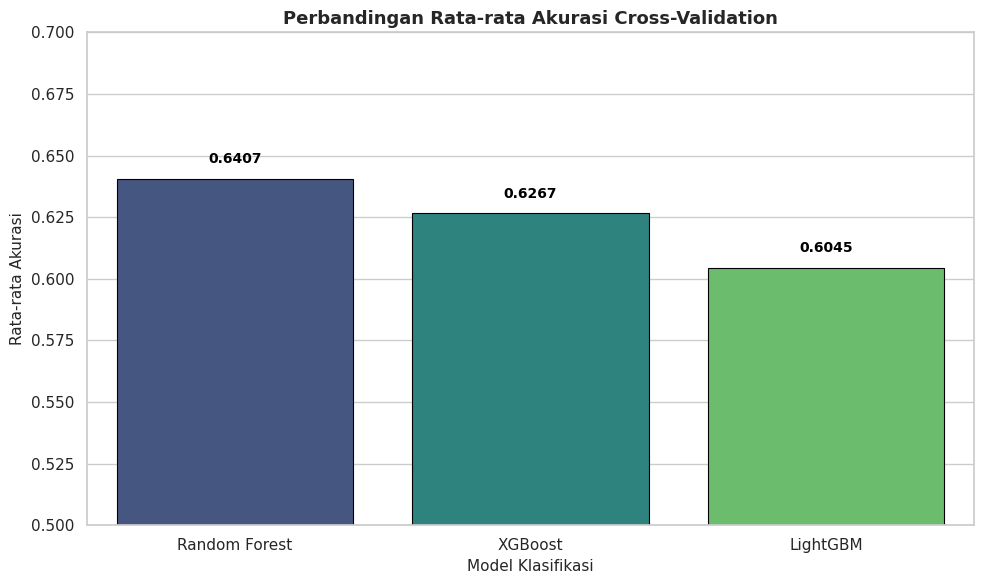

In [ ]:
# Calculate mean accuracies for all models
rf_mean_accuracy = cv_scores.mean()
xgb_mean_accuracy = cv_xgb_scores.mean()
lgbm_mean_accuracy = cv_lgbm_scores.mean()

# Create a DataFrame for plotting
model_comparison_df_all = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM'],
    'Mean Accuracy': [rf_mean_accuracy, xgb_mean_accuracy, lgbm_mean_accuracy]
})

# Create the bar plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Model', y='Mean Accuracy', data=model_comparison_df_all, palette='viridis', ax=ax,
            edgecolor='black', linewidth=0.8)

# Add accuracy values on top of the bars
for index, row in model_comparison_df_all.iterrows():
    ax.text(index, row['Mean Accuracy'] + 0.005, f'{row['Mean Accuracy']:.4f}',
            color='black', ha="center", va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0.5, 0.7)
ax.set_title('Perbandingan Rata-rata Akurasi Cross-Validation', fontsize=13, fontweight='bold')
ax.set_xlabel('Model Klasifikasi', fontsize=11)
ax.set_ylabel('Rata-rata Akurasi', fontsize=11)
plt.tight_layout()
plt.show()

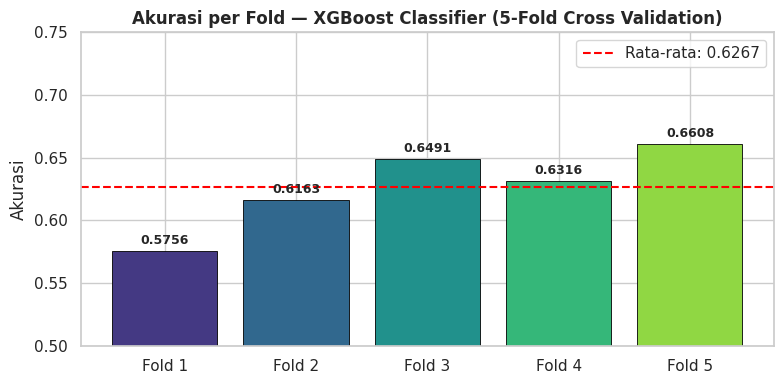

In [ ]:
# Visualisasi hasil cross validation XGBoost
fig, ax = plt.subplots(figsize=(8, 4))
fold_labels = [f'Fold {i}' for i in range(1, 6)]

bars = ax.bar(fold_labels, cv_xgb_scores, color=sns.color_palette('viridis', 5),
              edgecolor='black', linewidth=0.6)
ax.axhline(cv_xgb_scores.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Rata-rata: {cv_xgb_scores.mean():.4f}')

for bar, val in zip(bars, cv_xgb_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0.5, 0.75)
ax.set_title('Akurasi per Fold — XGBoost Classifier (5-Fold Cross Validation)', fontsize=12, fontweight='bold')
ax.set_ylabel('Akurasi')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretasi:** Visualisasi ini menunjukkan akurasi model XGBoost pada setiap *fold* selama proses validasi silang. Garis putus-putus merah merepresentasikan rata-rata akurasi keseluruhan. Sama seperti Random Forest, akurasi antar *fold* cukup konsisten, menunjukkan stabilitas model.

In [ ]:
# Inisialisasi model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=500,        # jumlah pohon keputusan
    max_features='sqrt',     # jumlah fitur yang dipertimbangkan di setiap split
    min_samples_leaf=1,      # jumlah minimum sampel di daun pohon
    random_state=42,         # untuk reprodusibilitas
    n_jobs=-1                # menggunakan semua core CPU
)

# Stratified K-Fold Cross Validation
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')

print(' Hasil Cross Validation (5-Fold) ')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\n  Rata-rata Akurasi : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
print(f'  Standar Deviasi   : {cv_scores.std():.4f}')

 Hasil Cross Validation (5-Fold) 
  Fold 1: 0.5756
  Fold 2: 0.6512
  Fold 3: 0.6374
  Fold 4: 0.6608
  Fold 5: 0.6784

  Rata-rata Akurasi : 0.6407 (64.07%)
  Standar Deviasi   : 0.0352


**Interpretasi:** Model Random Forest menghasilkan rata-rata akurasi cross validation sebesar **±64.07%** dengan standar deviasi sekitar 3.5%. Nilai akurasi ini tergolong wajar untuk dataset wine quality yang memiliki 6 kelas dengan distribusi tidak seimbang. Standar deviasi yang relatif kecil menunjukkan bahwa performa model konsisten di setiap fold.

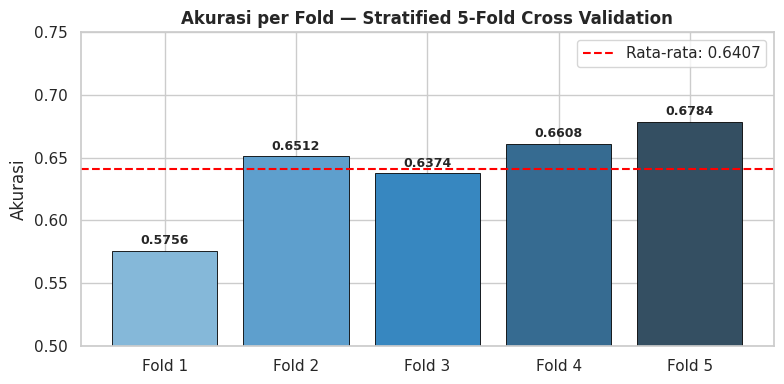

In [ ]:
# Visualisasi hasil cross validation
fig, ax = plt.subplots(figsize=(8, 4))
fold_labels = [f'Fold {i}' for i in range(1, 6)]

bars = ax.bar(fold_labels, cv_scores, color=sns.color_palette('Blues_d', 5),
              edgecolor='black', linewidth=0.6)
ax.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Rata-rata: {cv_scores.mean():.4f}')

for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0.5, 0.75)
ax.set_title('Akurasi per Fold — Stratified 5-Fold Cross Validation', fontsize=12, fontweight='bold')
ax.set_ylabel('Akurasi')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretasi:** Visualisasi ini menunjukkan akurasi model Random Forest pada setiap *fold* selama proses validasi silang. Garis putus-putus merah merepresentasikan rata-rata akurasi keseluruhan. Terlihat bahwa akurasi antar *fold* cukup konsisten dan tidak terlalu bervariasi, menegaskan bahwa model memiliki performa yang stabil dan mampu melakukan generalisasi dengan baik pada berbagai subset data training.

---
## 7. Pelatihan Model Final & Evaluasi

Setelah validasi silang, model dilatih menggunakan **seluruh data training** untuk mendapatkan model final yang akan digunakan memprediksi data testing.

In [ ]:
# Melatih model final pada seluruh data training
rf_model.fit(X_train_scaled, y_train)

# Prediksi pada data training (untuk evaluasi in-sample)
y_pred_train = rf_model.predict(X_train_scaled)

train_acc = accuracy_score(y_train, y_pred_train)
print(f'Akurasi pada Data Training: {train_acc:.4f} ({train_acc*100:.2f}%)')

Akurasi pada Data Training: 1.0000 (100.00%)


In [ ]:
# Classification Report
print(' Classification Report (Data Training) ')
print(classification_report(y_train, y_pred_train, zero_division=0))

 Classification Report (Data Training) 
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00       362
           6       1.00      1.00      1.00       341
           7       1.00      1.00      1.00       109
           8       1.00      1.00      1.00        13

    accuracy                           1.00       857
   macro avg       1.00      1.00      1.00       857
weighted avg       1.00      1.00      1.00       857



**Interpretasi:** Model mencapai akurasi 100% pada data training, yang menunjukkan adanya *overfitting* pada data latih, yakni kondisi umum pada Random Forest dengan kedalaman pohon penuh. Namun, hal ini tidak menjadi masalah selama performa pada data validasi (cross validation) tetap baik. Hasil cross validation sebesar ~64% adalah estimasi yang lebih realistis terhadap kemampuan generalisasi model.

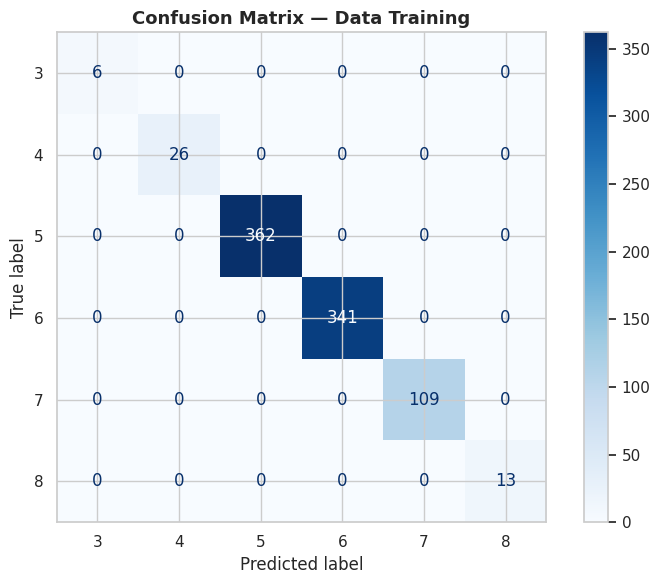

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_train, y_pred_train, labels=sorted(y_train.unique()))

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=sorted(y_train.unique()))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Data Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretasi:** Confusion matrix pada data training menunjukkan bahwa semua prediksi berada di diagonal utama (nilai sempurna), yang mengkonfirmasi bahwa model menghafalkan data training sepenuhnya. Pada data baru (testing), performa aktual diprakirakan sekitar 64% berdasarkan hasil cross validation.

---
## 8. Feature Importance

Analisis *feature importance* menunjukkan kontribusi relatif setiap fitur dalam proses pengambilan keputusan oleh model Random Forest.

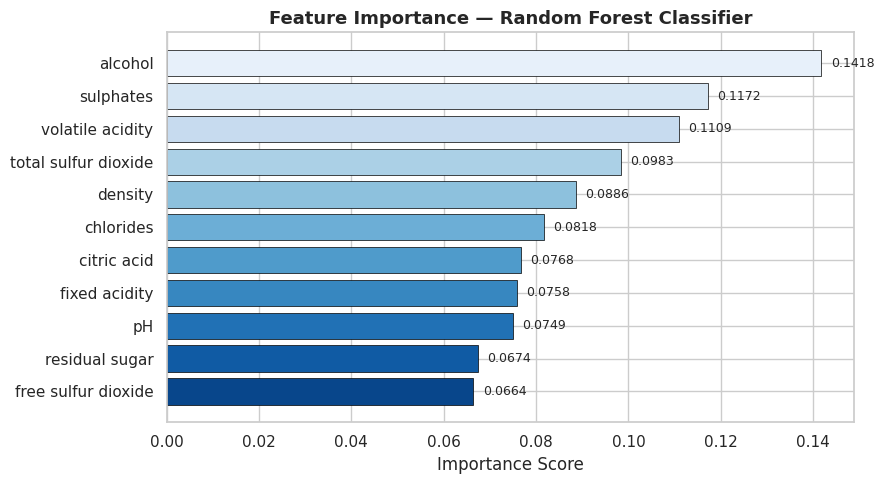


Ranking Feature Importance:
alcohol                 0.141808
sulphates               0.117209
volatile acidity        0.110929
total sulfur dioxide    0.098340
density                 0.088589
chlorides               0.081790
citric acid             0.076792
fixed acidity           0.075834
pH                      0.074913
residual sugar          0.067352
free sulfur dioxide     0.066444


In [ ]:
# Menghitung dan memvisualisasikan feature importance
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1f77b4' if v < importances_sorted.max() else '#d62728'
          for v in importances_sorted.values]
bars = ax.barh(importances_sorted.index, importances_sorted.values,
               color=sns.color_palette('Blues_r', len(feature_cols)),
               edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, importances_sorted.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('Feature Importance — Random Forest Classifier', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nRanking Feature Importance:')
print(importances.sort_values(ascending=False).to_string())

**Interpretasi:** Tiga fitur paling berpengaruh dalam memprediksi kualitas anggur adalah:
1. **`alcohol`** (0.1418) : Kadar alkohol merupakan fitur terpenting, konsisten dengan analisis korelasi sebelumnya.
2. **`sulphates`** (0.1172) : Kadar sulphates berkontribusi signifikan, kemungkinan terkait perannya sebagai antioksidan dan pengawet.
3. **`volatile acidity`** (0.1109) : Keasaman volatil yang tinggi menurunkan kualitas rasa anggur.

Sementara itu, `free sulfur dioxide` dan `residual sugar` memiliki pengaruh paling kecil dalam model ini.

---
## 9. Prediksi Data Testing

Model yang telah dilatih digunakan untuk memprediksi nilai `quality` pada data testing. Hasil prediksi disimpan dalam format CSV dengan hanya dua kolom: `Id` dan `quality`.

In [ ]:
# Prediksi kualitas pada data testing
y_pred_test = rf_model.predict(X_test_scaled)

# Membuat DataFrame hasil prediksi
hasil_prediksi = pd.DataFrame({
    'Id': test['Id'],
    'quality': y_pred_test
})

print('Preview hasil prediksi (10 baris pertama):')
print(hasil_prediksi.head(10))

print(f'\nTotal data yang diprediksi: {len(hasil_prediksi)} sampel')

Preview hasil prediksi (10 baris pertama):
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        5
5  1120        6
6   180        5
7    82        5
8   632        6
9   592        5

Total data yang diprediksi: 286 sampel


Distribusi Hasil Prediksi Data Testing:
quality
5    132
6    124
7     30
Name: count, dtype: int64


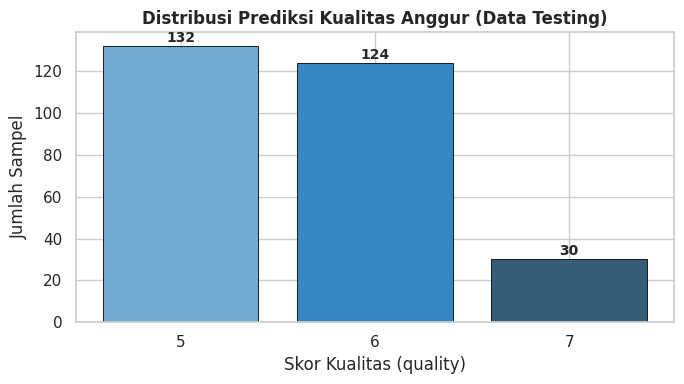

In [ ]:
# Distribusi hasil prediksi
pred_counts = hasil_prediksi['quality'].value_counts().sort_index()
print('Distribusi Hasil Prediksi Data Testing:')
print(pred_counts)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(pred_counts.index, pred_counts.values,
              color=sns.color_palette('Blues_d', len(pred_counts)),
              edgecolor='black', linewidth=0.6)

for bar, val in zip(bars, pred_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribusi Prediksi Kualitas Anggur (Data Testing)', fontsize=12, fontweight='bold')
ax.set_xlabel('Skor Kualitas (quality)')
ax.set_ylabel('Jumlah Sampel')
ax.set_xticks(pred_counts.index)
plt.tight_layout()
plt.show()

**Interpretasi:** Hasil prediksi pada 286 data testing menunjukkan dominasi kelas **5** (132 sampel) dan **6** (124 sampel), serta 30 sampel diprediksi berkualitas **7**. Tidak ada sampel yang diprediksi berkualitas sangat rendah (3–4) atau sangat tinggi (8), yang masuk akal mengingat sedikitnya contoh kelas-kelas tersebut dalam data training. Distribusi ini juga konsisten dengan pola distribusi pada data training.

In [ ]:
# Menyimpan hasil prediksi ke file CSV
nama_file = 'hasilprediksi_034.csv'

hasil_prediksi.to_csv(nama_file, index=False)
print(f'Hasil prediksi berhasil disimpan sebagai: {nama_file}')
print('\nVerifikasi file:')
print(pd.read_csv(nama_file).head())
print(f'\nKolom: {pd.read_csv(nama_file).columns.tolist()}')
print(f'Jumlah baris: {len(pd.read_csv(nama_file))}')

Hasil prediksi berhasil disimpan sebagai: hasilprediksi_034.csv

Verifikasi file:
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        5

Kolom: ['Id', 'quality']
Jumlah baris: 286


---
## 10. Kesimpulan

Berikut adalah rangkuman dari seluruh proses yang dilakukan dalam analisis ini:

| Tahap | Keterangan |
|-------|------------|
| **Dataset** | 857 data training, 286 data testing, 11 fitur kimiawi |
| **Missing Values** | Tidak ditemukan missing values pada kedua dataset |
| **Preprocessing** | Normalisasi fitur menggunakan StandardScaler |
| **Model** | Random Forest Classifier (500 pohon, `max_features='sqrt'`) |
| **Evaluasi** | Stratified 5-Fold Cross Validation |
| **Akurasi CV** | ~64.07% ± 3.52% |
| **Fitur Terpenting** | `alcohol`, `sulphates`, `volatile acidity` |
| **Output** | 286 prediksi kualitas (kelas 5, 6, dan 7) |

**Kesimpulan:** Model Random Forest yang dibangun mampu mengklasifikasikan kualitas anggur dengan akurasi validasi silang sekitar 64%. Performa ini cukup wajar mengingat tantangan dataset yang memiliki 6 kelas dengan distribusi sangat tidak seimbang. Fitur `alcohol` terbukti menjadi prediktor terkuat kualitas anggur, diikuti oleh `sulphates` dan `volatile acidity`.